# Import Library dan Dataset

In [32]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

spark = SparkSession.builder \
    .appName('DustiniaDelixia_Groceria_EDA') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)
print('SparkSession ready ✓')

Spark version: 4.0.2
SparkSession ready ✓


In [33]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

from pyspark.sql import Window

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cek Tabel, Kolom, dan Baris yang Ada

In [35]:
# DustiniaDelixia_Groceria

DATA_DIR = '/content/drive/MyDrive/DustiniaDelixia_Groceria'

FILES = [
    "orders",
    "order_items",
    "sellers",
    "customers",
    "geolocation",
    "order_reviews",
    "products",
    "category_translation",
    "order_payments",
    "closed_deals",
    "mql",
]

dfs = {}
for name in FILES:
    path = f"{DATA_DIR}/{name}.csv"

    dfs[name] = spark.read.option("header", True).option("inferSchema", True).option("multiLine", True).option("quote", '"').option("escape", '"').csv(path)

    print(f"{name:30s} {dfs[name].count():>8,} rows  {len(dfs[name].columns):>3} cols")

orders                           99,441 rows    8 cols
order_items                     112,650 rows    7 cols
sellers                           3,095 rows    4 cols
customers                        99,441 rows    5 cols
geolocation                    1,000,163 rows    5 cols
order_reviews                    99,224 rows    7 cols
products                         32,951 rows    9 cols
category_translation                 71 rows    2 cols
order_payments                  103,886 rows    5 cols
closed_deals                        842 rows   14 cols
mql                               8,000 rows    4 cols


# Cek Tipe Data

In [36]:
for name, df in dfs.items():
    print(f"TABLE: {name}")
    df.printSchema()
    print("\n")

TABLE: orders
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



TABLE: order_items
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)



TABLE: sellers
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)



TABLE: cust

#### Didapatkan beberapa hal yang bisa menjadi anomali pada tipe data untuk pemrosesan ke depannya.

a. Inkonsistensi tipe data pada kolom id. Hampir semua id berupa string, kecuali pada **order_item_id** yang berupa integer.

b. Kolom zip_code (**seller, costumer, geolocation**) berupa integer. Perlu diperiksa apakah sebaiknya diubah ke string.

c. Kolom **review_score** berupa string. Perlu diperiksa apakah sebaiknya diubah ke integer.

d. Kolom **product_name_lenght, product_description_lenght, product_photos_qty** berupa double. Perlu diperiksa apakah sebaiknya diubah ke integer. **(SOLVED)**

e. Kolom  **review_creation_date, review_answer_timestamp** berupa string. Sekilas diketahui bahwa sebaiknya diubah ke timestamp. **(SOLVED)**

### a. Analisis tipe data order_item_id

Tidak ditemukan masalah kualitas data.
`order_item_id` merepresentasikan urutan item dalam suatu order,
sehingga tipe integer masih sesuai dan tidak memerlukan transformasi.

### b. Analisis tipe data zip_code

In [37]:
dfs['customers'] \
.select(
    F.min(F.length(F.col('customer_zip_code_prefix').cast('string'))),
    F.max(F.length(F.col('customer_zip_code_prefix').cast('string')))
).show()

dfs['geolocation'] \
.select(
    F.min(F.length(F.col('geolocation_zip_code_prefix').cast('string'))),
    F.max(F.length(F.col('geolocation_zip_code_prefix').cast('string')))
).show()

+-----------------------------------------------------+-----------------------------------------------------+
|min(length(CAST(customer_zip_code_prefix AS STRING)))|max(length(CAST(customer_zip_code_prefix AS STRING)))|
+-----------------------------------------------------+-----------------------------------------------------+
|                                                    4|                                                    5|
+-----------------------------------------------------+-----------------------------------------------------+

+--------------------------------------------------------+--------------------------------------------------------+
|min(length(CAST(geolocation_zip_code_prefix AS STRING)))|max(length(CAST(geolocation_zip_code_prefix AS STRING)))|
+--------------------------------------------------------+--------------------------------------------------------+
|                                                       4|                                           

#### Hasil analisis:
Ditemukan panjang kode 4–5 digit pada data sumber.
Kolom ini merepresentasikan kode wilayah/zip code dan bukan nilai numerik
yang digunakan untuk perhitungan.

#### Tindakan transform:
Disarankan mengubah tipe data menjadi string untuk menjaga konsistensi
sebagai identifier geografis dan menghindari potensi masalah formatting
pada proses integrasi data berikutnya.

### c. Analisis tipe data review_score

In [38]:
(
    dfs["order_reviews"]
    .select("review_score")
    .distinct()
    .orderBy("review_score")
    .show()
)

+------------+
|review_score|
+------------+
|           1|
|           2|
|           3|
|           4|
|           5|
+------------+



#### Hasil analisis:
Distinct value menunjukkan hanya terdapat nilai 1–5
dan tidak ditemukan karakter non-numerik.

#### Tindakan transform:
Mengubah tipe data menjadi integer karena kolom merepresentasikan rating
ordinal dan seluruh nilai valid untuk dikonversi.

### d. Penanganan tipe data double yang tidak sesuai

#### Hasil analisis:
Ketiga kolom (`product_name_lenght, product_description_lenght, product_photos_qty`) merepresentasikan jumlah karakter atau jumlah foto
yang secara konsep merupakan bilangan diskrit.

#### Tindakan transform:
Mengubah tipe data menjadi integer.

### e. Penanganan tipe data timestamp yang tidak sesuai

#### Hasil analisis:
Nilai ` review_creation_date, review_answer_timestamp` mengikuti pola tanggal dan waktu (datetime).

#### Tindakan transform:
Mengubah tipe data menjadi timestamp agar dapat digunakan
untuk analisis temporal dan perhitungan waktu.

# Cek Nilai Null

In [39]:
for name, df in dfs.items():
    total = df.count()
    null_exprs = [F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns]
    null_counts = df.select(null_exprs).collect()[0].asDict()

    has_null = any(v > 0 for v in null_counts.values())
    print(f"TABLE: {name}  ({total:,} rows)")

    if not has_null:
        print("Tidak ada null\n")
    else:
        for col, cnt in null_counts.items():
            if cnt > 0:
                print(f"  {col:45s} {cnt:>8,} ({cnt/total*100:5.1f}%)")

        print("\n")

TABLE: orders  (99,441 rows)
  order_approved_at                                  160 (  0.2%)
  order_delivered_carrier_date                     1,783 (  1.8%)
  order_delivered_customer_date                    2,965 (  3.0%)


TABLE: order_items  (112,650 rows)
Tidak ada null

TABLE: sellers  (3,095 rows)
Tidak ada null

TABLE: customers  (99,441 rows)
Tidak ada null

TABLE: geolocation  (1,000,163 rows)
Tidak ada null

TABLE: order_reviews  (99,224 rows)
  review_comment_title                            87,656 ( 88.3%)
  review_comment_message                          58,247 ( 58.7%)


TABLE: products  (32,951 rows)
  product_category_name                              610 (  1.9%)
  product_name_lenght                                610 (  1.9%)
  product_description_lenght                         610 (  1.9%)
  product_photos_qty                                 610 (  1.9%)
  product_weight_g                                     2 (  0.0%)
  product_length_cm                        

# Cek Nilai Null (Visualisasi)


orders


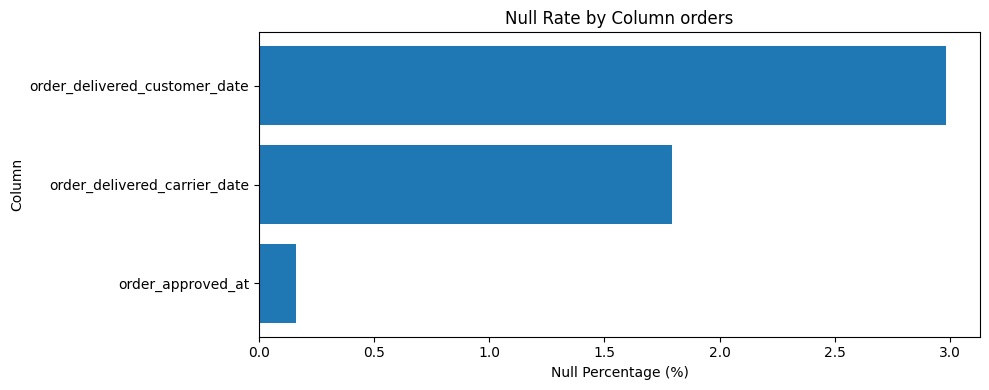


order_items
Tidak ada null

sellers
Tidak ada null

customers
Tidak ada null

geolocation
Tidak ada null

order_reviews


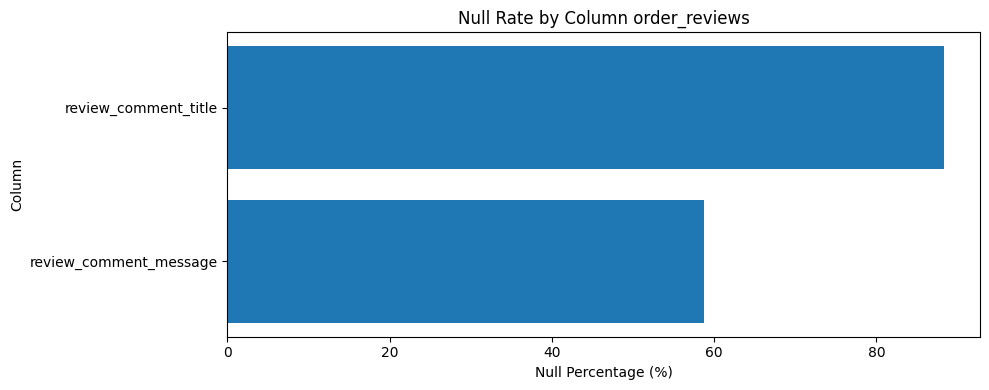


products


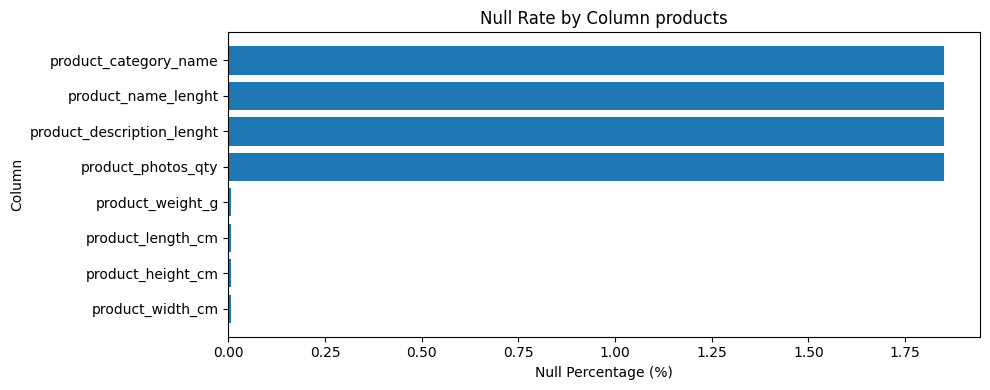


category_translation
Tidak ada null

order_payments
Tidak ada null

closed_deals


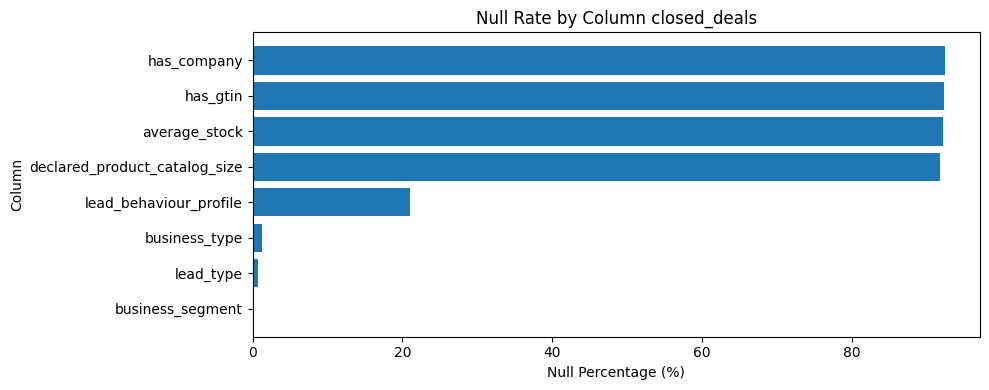


mql


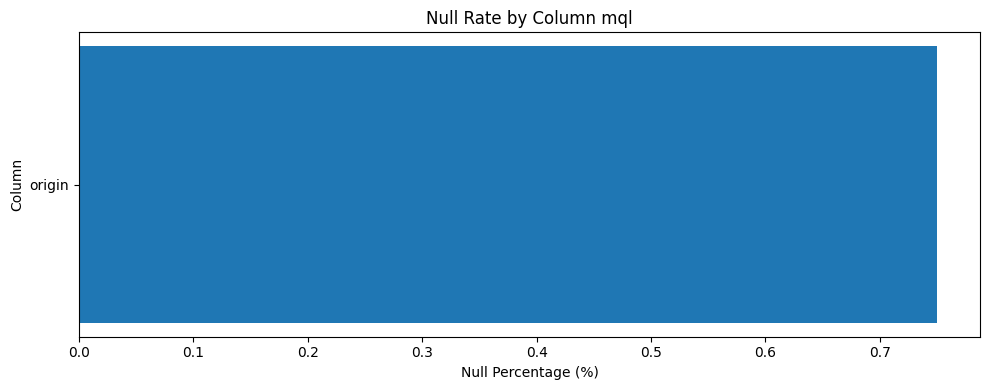

In [40]:
for name, df in dfs.items():

    total = df.count()

    null_exprs = [
        F.sum(F.col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]

    null_counts = (
        df.select(null_exprs)
        .collect()[0]
        .asDict()
    )

    rows = []

    print(f"\n{name}")
    for col, cnt in null_counts.items():
        if cnt > 0:
            rows.append({
                "column": col,
                "null_count": cnt,
                "null_pct": cnt / total * 100
            })

    if not rows:
        print("Tidak ada null")
        continue

    pdf = (
        pd.DataFrame(rows)
        .sort_values("null_pct", ascending=True)
    )

    plt.figure(figsize=(10, max(4, len(pdf) * 0.5)))

    plt.barh(
        pdf["column"],
        pdf["null_pct"]
    )

    plt.xlabel("Null Percentage (%)")
    plt.ylabel("Column")
    plt.title(f"Null Rate by Column {name}")

    plt.tight_layout()
    plt.show()

Dari hasil pemeriksaan nilai NULL, didapatkan beberapa tabel yang memiliki kolom null.

a. orders

b. order_reviews

c. products

d. closed_deals

e. mql

### Memerika nilai NULL pada tabel orders

In [41]:
dfs["orders"] \
.groupBy("order_status") \
.agg(
    F.sum(
        F.col("order_approved_at")
        .isNull()
        .cast("int")
    ).alias("order_approved_at == null")
) \
.orderBy("order_approved_at == null", ascending=False) \
.show(truncate=False)

+------------+-------------------------+
|order_status|order_approved_at == null|
+------------+-------------------------+
|canceled    |141                      |
|delivered   |14                       |
|created     |5                        |
|shipped     |0                        |
|approved    |0                        |
|invoiced    |0                        |
|unavailable |0                        |
|processing  |0                        |
+------------+-------------------------+



In [42]:
dfs["orders"] \
.groupBy("order_status") \
.agg(
    F.sum(
        F.col("order_delivered_carrier_date")
        .isNull()
        .cast("int")
    ).alias("order_delivered_carrier_date == null")
) \
.orderBy("order_delivered_carrier_date == null", ascending=False) \
.show(truncate=False)

+------------+------------------------------------+
|order_status|order_delivered_carrier_date == null|
+------------+------------------------------------+
|unavailable |609                                 |
|canceled    |550                                 |
|invoiced    |314                                 |
|processing  |301                                 |
|created     |5                                   |
|approved    |2                                   |
|delivered   |2                                   |
|shipped     |0                                   |
+------------+------------------------------------+



In [43]:
dfs["orders"] \
.groupBy("order_status") \
.agg(
    F.sum(
        F.col("order_delivered_customer_date")
        .isNull()
        .cast("int")
    ).alias("order_delivered_customer_date == null")
) \
.orderBy("order_delivered_customer_date == null", ascending=False) \
.show(truncate=False)

+------------+-------------------------------------+
|order_status|order_delivered_customer_date == null|
+------------+-------------------------------------+
|shipped     |1107                                 |
|canceled    |619                                  |
|unavailable |609                                  |
|invoiced    |314                                  |
|processing  |301                                  |
|delivered   |8                                    |
|created     |5                                    |
|approved    |2                                    |
+------------+-------------------------------------+



### Analisis:
- Sebagian besar nilai null berasal dari order yang masih berada pada tahap awal proses (created, approved, invoiced, processing, shipped) atau order yang tidak berhasil diselesaikan (canceled, unavailable), sehingga wajar jika ada nilai null pada kolom yang menyatakan bahwa produk sudah diterima kurir/customer.

- Ditemukan inkonsistensi, seperti order yang delivered tapi timestamp diterima pelanggan masih null. Namun, jumlahnya sangat kecil jadi bisa dikatakan sebagai inkonsistensi minor.

### Tindakan:
Kita akan pertahankan nilai null sebagaimana adanya

### Memeriksa nilai NULL pada tabel order_reviews

Kolom yang berisi nilai NULL pada order_reviews hanya review_comment_title dan review_comment_message. Hal ini sangat wajar karena banyak customer yang memberi review/rating tanpa memberikan judul dan/atau komentar dari rating tersebut.

**Misal: Hanya memberi bintang 5, tanpa ada judul/komentar dari rating tersebut**

**Tindakan:**
Kita pertahankan nilai null sebagaimana adanya

### Memeriksa nilai NULL pada tabel products

In [44]:
products = dfs["products"]

products.filter(
    F.col("product_category_name").isNull()
).select(
    "product_id",
    "product_category_name",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_height_cm",
    "product_width_cm"
).show(20, truncate=False)

+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+----------------+
|a41e356c76fab66334f36de622ecbd3a|NULL                 |NULL               |NULL                      |NULL              |650.0           |14.0             |12.0            |
|d8dee61c2034d6d075997acef1870e9b|NULL                 |NULL               |NULL                      |NULL              |300.0           |7.0              |20.0            |
|56139431d72cd51f19eb9f7dae4d1617|NULL                 |NULL               |NULL                      |NULL              |200

In [45]:
products.filter(
    F.col("product_weight_g").isNull()
).select(
    "product_id",
    "product_category_name",
    "product_weight_g",
    "product_height_cm",
    "product_width_cm"
).show(truncate=False)

+--------------------------------+---------------------+----------------+-----------------+----------------+
|product_id                      |product_category_name|product_weight_g|product_height_cm|product_width_cm|
+--------------------------------+---------------------+----------------+-----------------+----------------+
|09ff539a621711667c43eba6a3bd8466|bebes                |NULL            |NULL             |NULL            |
|5eb564652db742ff8f28759cd8d2652a|NULL                 |NULL            |NULL             |NULL            |
+--------------------------------+---------------------+----------------+-----------------+----------------+



In [46]:
null_products = dfs["products"].filter(
    F.col("product_category_name").isNull()
)

dfs["order_items"].join(
    null_products.select("product_id"),
    "product_id",
    "inner"
).count()

1603

### Analisis:

Ditemukan 610 produk yang tidak memiliki metadata deskriptif:
- product_category_name
- product_name_lenght
- product_description_lenght
- product_photos_qty

Tetapi, produk ini masih memiliki informasi berat dan dimensi (weight, height, dan length). Bahkan, setelah dilakukan JOIN dengan tabel order_items, produk-produk tanpa metadata ini terlibat dalam 1,603 record transaksi.

Sehingga, disimpulkan bahwa produk tanpa metadata masih layak digunakan.

### Tindakan:
Kita pertahankan nilai null sebagaimana adanya

### Memeriksa nilai NULL pada tabel closed_deals

In [47]:
dfs["closed_deals"].select(
    "has_company",
    "has_gtin",
    "average_stock",
    "declared_product_catalog_size"
).show(20, truncate=False)

+-----------+--------+-------------+-----------------------------+
|has_company|has_gtin|average_stock|declared_product_catalog_size|
+-----------+--------+-------------+-----------------------------+
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                         |
|NULL       |NULL    |NULL         |NULL                      

In [48]:
for c in [
    "has_company",
    "has_gtin",
    "average_stock",
    "declared_product_catalog_size"
]:
    print(f"\n{c}")
    dfs["closed_deals"].groupBy(c).count().show()


has_company
+-----------+-----+
|has_company|count|
+-----------+-----+
|       NULL|  779|
|       true|   58|
|      false|    5|
+-----------+-----+


has_gtin
+--------+-----+
|has_gtin|count|
+--------+-----+
|    NULL|  778|
|    true|   54|
|   false|   10|
+--------+-----+


average_stock
+-------------+-----+
|average_stock|count|
+-------------+-----+
|         200+|    7|
|         5-20|   22|
|      unknown|    4|
|         NULL|  776|
|       50-200|   15|
|          1-5|   10|
|        20-50|    8|
+-------------+-----+


declared_product_catalog_size
+-----------------------------+-----+
|declared_product_catalog_size|count|
+-----------------------------+-----+
|                        305.0|    1|
|                         70.0|    2|
|                        800.0|    1|
|                         75.0|    1|
|                         47.0|    1|
|                         NULL|  773|
|                         80.0|    1|
|                        120.0|    2|
|        

In [49]:
for c in [
    "business_segment",
    "lead_type",
    "lead_behaviour_profile",
    "has_company",
    "has_gtin",
    "average_stock",
    "business_type",
    "declared_product_catalog_size"
]:
    print(f"\n{c}:")
    dfs["closed_deals"].groupBy(c).count().show(truncate=False)


business_segment:
+-------------------+-----+
|business_segment   |count|
+-------------------+-----+
|small_appliances   |12   |
|bed_bath_table     |22   |
|computers          |34   |
|NULL               |1    |
|religious          |1    |
|handcrafted        |12   |
|stationery         |13   |
|home_decor         |105  |
|other              |3    |
|gifts              |5    |
|food_supplement    |28   |
|party              |5    |
|jewerly            |8    |
|books              |9    |
|air_conditioning   |3    |
|household_utilities|71   |
|health_beauty      |93   |
|home_appliances    |7    |
|music_instruments  |9    |
|pet                |30   |
+-------------------+-----+
only showing top 20 rows

lead_type:
+---------------+-----+
|lead_type      |count|
+---------------+-----+
|industry       |123  |
|online_top     |14   |
|online_beginner|57   |
|NULL           |6    |
|offline        |104  |
|online_big     |126  |
|online_small   |77   |
|other          |3    |
|online_

### Analisis:

Ditemukan nilai null pada beberapa kolom, terutama:
- lead_behaviour_profile (21.0%)
- has_company (92.5%)
- has_gtin (92.4%)
- average_stock (92.2%)
- declared_product_catalog_size (91.8%)

Sebagian besar nilai null berasal dari informasi tambahan yang kemungkinan bersifat opsional dan tidak diisi oleh lead. Tidak ditemukan indikasi kuat adanya kerusakan data.

### Tindakan:
Kita pertahankan nilai null sebagaimana adanya

### Memeriksa nilai NULL pada tabel mql

In [50]:
dfs["mql"].groupBy("origin").count().orderBy(F.desc("count")).show(50, truncate=False)

+-----------------+-----+
|origin           |count|
+-----------------+-----+
|organic_search   |2296 |
|paid_search      |1586 |
|social           |1350 |
|unknown          |1099 |
|direct_traffic   |499  |
|email            |493  |
|referral         |284  |
|other            |150  |
|display          |118  |
|other_publicities|65   |
|NULL             |60   |
+-----------------+-----+



### Analisis:

Ditemukan nilai null pada kolom:
- origin (0.8%)

Kolom origin adalah sumber perolehan lead, dan memiliki kategori seperti unknown. Hal ini adalah indikasi bahwa nilai null pada kolom origin adalah hal yang wajar, bisa berupa sumber lead yang memang tidak terdata. Apalagi, nilainya relatif kecul dan tidak akan menghasilkan kecatatan proses selanjutnya.

### Tindakan:
Kita pertahankan nilai null sebagaimana adanya

# Cek Duplikat

In [51]:
for name, df in dfs.items():
    total = df.count()
    distinct = df.dropDuplicates().count()
    dup = total - distinct
    print(f"{name:25s} total: {total:>8,}  distinct: {distinct:>8,}  duplikat: {dup:>6,}")

orders                    total:   99,441  distinct:   99,441  duplikat:      0
order_items               total:  112,650  distinct:  112,650  duplikat:      0
sellers                   total:    3,095  distinct:    3,095  duplikat:      0
customers                 total:   99,441  distinct:   99,441  duplikat:      0
geolocation               total: 1,000,163  distinct:  738,332  duplikat: 261,831
order_reviews             total:   99,224  distinct:   99,224  duplikat:      0
products                  total:   32,951  distinct:   32,951  duplikat:      0
category_translation      total:       71  distinct:       71  duplikat:      0
order_payments            total:  103,886  distinct:  103,886  duplikat:      0
closed_deals              total:      842  distinct:      842  duplikat:      0
mql                       total:    8,000  distinct:    8,000  duplikat:      0


### Hanya ada tabel yang memiliki duplikat, yaitu geolocation. Maka, dilakukan analisis seperti di bawah:

In [52]:
dfs["geolocation"] \
    .groupBy(dfs["geolocation"].columns) \
    .count() \
    .filter("count > 1") \
    .orderBy(F.desc("count")) \
    .show(20, truncate=False)

+---------------------------+-------------------+-------------------+---------------------+-----------------+-----+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng    |geolocation_city     |geolocation_state|count|
+---------------------------+-------------------+-------------------+---------------------+-----------------+-----+
|88220                      |-27.102098999999946|-48.62961349999995 |itapema              |SC               |314  |
|6414                       |-23.495901469908656|-46.87468669635919 |barueri              |SP               |189  |
|6414                       |-23.490617505282756|-46.86900366603934 |barueri              |SP               |127  |
|5145                       |-23.506049208479613|-46.71737739541604 |sao paulo            |SP               |126  |
|22620                      |-23.00551425914832 |-43.37596441256672 |rio de janeiro       |RJ               |102  |
|22640                      |-23.004582245036413|-43.319899315692446|rio

### Analisis:

Ditemukan 261.831 baris duplikat (26.2%).

Duplikasi terjadi pada seluruh atribut geolokasi (zip code, koordinat, kota, dan state) yang identik, sehingga tidak menambahkan informasi baru.

### Tindakan:
- Hapus baris duplikat pada tahap transformasi menggunakan distinct() atau dropDuplicates().
- Pertahankan satu representasi unik untuk setiap kombinasi geolokasi.

# Cek Nilai di Luar Batas

### Apakah ada harga dan ongkos yang <=0? (Tidak masuk akal, harusnya ada harganya)

In [53]:
dfs['order_items'].filter(
    (F.col('price') <= 0) | (F.col('freight_value') < 0)
).show(10)

+--------+-------------+----------+---------+-------------------+-----+-------------+
|order_id|order_item_id|product_id|seller_id|shipping_limit_date|price|freight_value|
+--------+-------------+----------+---------+-------------------+-----+-------------+
+--------+-------------+----------+---------+-------------------+-----+-------------+



#### Analisis:
Tidak ada harga produk yang bernilai nol atau negatif.

#### Aman dari transformasi

### Apakah ada pembayaran yang 0? Apakah ada data berat dan dimensi produk yang <= 0? Apakah ada lokasi yang di luar Brazil?

In [54]:
# order_payments
print("=== order_payments ===")
dfs['order_payments'].filter(
    (F.col('payment_value') <= 0) |
    (F.col('payment_installments') <= 0)
).show(10)

# products - dimensi fisik tidak boleh 0 atau negatif
print("=== products ===")
dfs['products'].filter(
    (F.col('product_weight_g') <= 0) |
    (F.col('product_length_cm') <= 0) |
    (F.col('product_height_cm') <= 0) |
    (F.col('product_width_cm') <= 0)
).show(10)

# geolocation - lat/lng Brazil seharusnya di rentang tertentu
print("=== geolocation ===")
dfs['geolocation'].filter(
    (F.col('geolocation_lat') < -35) | (F.col('geolocation_lat') > 5) |
    (F.col('geolocation_lng') < -75) | (F.col('geolocation_lng') > -30)
).show(10)

=== order_payments ===
+--------------------+------------------+------------+--------------------+-------------+
|            order_id|payment_sequential|payment_type|payment_installments|payment_value|
+--------------------+------------------+------------+--------------------+-------------+
|8bcbe01d44d147f90...|                 4|     voucher|                   1|          0.0|
|fa65dad1b0e818e3c...|                14|     voucher|                   1|          0.0|
|6ccb433e00daae128...|                 4|     voucher|                   1|          0.0|
|744bade1fcf9ff3f3...|                 2| credit_card|                   0|        58.69|
|4637ca194b6387e2d...|                 1| not_defined|                   1|          0.0|
|00b1cb0320190ca0d...|                 1| not_defined|                   1|          0.0|
|45ed6e85398a87c25...|                 3|     voucher|                   1|          0.0|
|fa65dad1b0e818e3c...|                13|     voucher|                   1|  

##### Memeriksa geolocation

In [55]:
dfs["geolocation"].filter(
    (F.col("geolocation_lat") < -35) |
    (F.col("geolocation_lat") > 5) |
    (F.col("geolocation_lng") < -75) |
    (F.col("geolocation_lng") > -30)
).count()

29

#### Analisis:
- Ditemukan beberapa payment_value = 0, tetapi setelah ditelusuri pembayaran tersebut berasal dari voucher dan not_defined. Voucher bisa membuat pembayaran gratis, dan pembayaran yang gagal (not_defined) tidak akan memiliki nominal.
- Ditemukan beberapa produk yang tidak memiliki berat (product_weight_g = 0). Tetapi jumlahnya sangat kecil, yaitu hanya 4 produk.
- Ditemukan 29 lokasi yang di luar koordinat geografis negara Brazil.

#### Tindakan:
Lokasi yang di luar wilayah Brazil bisa dipertimbangkan untuk dihapus.


### Apakah ada timestamp aneh, yaitu disetujui sebelum melakukan purchase, dikirim ke kurir sebelum disetujui, dan dikirim ke customer sebelum dikirim ke kurir?

In [56]:
dfs["orders"].filter(
    F.col("order_approved_at") < F.col("order_purchase_timestamp")
).count()

0

In [57]:
dfs["orders"].filter(
    F.col("order_delivered_carrier_date") < F.col("order_approved_at")
).count()

1359

In [58]:
dfs["orders"].filter(
    F.col("order_delivered_customer_date") < F.col("order_delivered_carrier_date")
).count()

23

##### Memeriksa timestamp aneh

In [59]:
(
    dfs["orders"]
    .filter(
        F.col("order_delivered_carrier_date")
        < F.col("order_approved_at")
    )
    .select(
        (
            F.unix_timestamp("order_approved_at")
            -
            F.unix_timestamp("order_delivered_carrier_date")
        ).alias("diff_seconds")
    )
    .select(
        F.min("diff_seconds"),
        F.max("diff_seconds"),
        F.avg("diff_seconds")
    )
    .show()
)

+-----------------+-----------------+-----------------+
|min(diff_seconds)|max(diff_seconds)|avg(diff_seconds)|
+-----------------+-----------------+-----------------+
|               21|         14793322|89107.15305371597|
+-----------------+-----------------+-----------------+



In [60]:
(
    dfs["orders"]
    .filter(
        F.col("order_delivered_carrier_date")
        < F.col("order_approved_at")
    )
    .groupBy("order_status")
    .count()
    .show()
)

+------------+-----+
|order_status|count|
+------------+-----+
|     shipped|    9|
|   delivered| 1350|
+------------+-----+



In [69]:
dfs["orders"].filter(
    F.col("order_delivered_carrier_date") < F.col("order_approved_at")
).select(
    (
        F.unix_timestamp("order_approved_at") -
        F.unix_timestamp("order_delivered_carrier_date")
    ).alias("diff_seconds")
).select(
    F.count("diff_seconds").alias("total"),
    F.sum((F.col("diff_seconds") < 300).cast("int")).alias("< 5 menit"),
    F.sum((F.col("diff_seconds").between(300, 3600)).cast("int")).alias("5 menit - 1 jam"),
    F.sum((F.col("diff_seconds").between(3600, 86400)).cast("int")).alias("1 jam - 1 hari"),
    F.sum((F.col("diff_seconds") > 86400).cast("int")).alias("> 1 hari"),
).show()

+-----+---------+---------------+--------------+--------+
|total|< 5 menit|5 menit - 1 jam|1 jam - 1 hari|> 1 hari|
+-----+---------+---------------+--------------+--------+
| 1359|       17|            225|           659|     458|
+-----+---------+---------------+--------------+--------+



#### Analisis:
- Ditemukan order yang tercatat diserahkan ke kurir sebelum disetujui (order_delivered_carrier_date < order_approved_at)
- Terdapat irder yang tercatat diterima customer sebelum diterima kurir (order_delivered_customer_date < order_delivered_carrier_date).


#### Tindakan:
- Karena anomali berupa ketidakmungkinan logis, maka semua data yang tidak sesuai tersebut didrop pada tahap transformasi.
- Untuk kasus order_delivered_customer_date < order_delivered_carrier_date, jumlahnya kecil sehingga drop tidak akan berpengaruh besar.
- Untuk kasus order_delivered_carrier_date < order_approved_at, walau jumlahnya banyak, ada banyak juga order yang selisih waktu anomalinya lebih dari 1 hari, ini bukan kesalahan pada sistem, memang ada kecacatan kualitas data.

### Apakah ada review score yang keluar rentang 1 - 5?

In [61]:
dfs["order_reviews"].filter(
    (F.col("review_score") < 1) |
    (F.col("review_score") > 5)
).count()

0

#### Tidak ada masalah dalam rentang review score

# Ini nantian aja buat distribusi

In [62]:
# order_status distribution
print("=== order_status ===")
dfs['orders'].groupBy('order_status') \
    .count() \
    .orderBy(F.desc('count')) \
    .show()

# Distribusi seller per state
print("=== seller per state (top 10) ===")
dfs['sellers'].groupBy('seller_state') \
    .count() \
    .orderBy(F.desc('count')) \
    .show(10)

# Distribusi customer per state
print("=== customer per state (top 10) ===")
dfs['customers'].groupBy('customer_state') \
    .count() \
    .orderBy(F.desc('count')) \
    .show(10)

# Distribusi items per order
print("=== items per order ===")
dfs['order_items'].groupBy('order_id') \
    .count() \
    .select(
        F.min('count').alias('min_items'),
        F.max('count').alias('max_items'),
        F.avg('count').alias('avg_items'),
    ).show()

# Distribusi review score
print("=== review score ===")
dfs['order_reviews'].groupBy('review_score') \
    .count() \
    .orderBy('review_score') \
    .show()

=== order_status ===
+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+

=== seller per state (top 10) ===
+------------+-----+
|seller_state|count|
+------------+-----+
|          SP| 1849|
|          PR|  349|
|          MG|  244|
|          SC|  190|
|          RJ|  171|
|          RS|  129|
|          GO|   40|
|          DF|   30|
|          ES|   23|
|          BA|   19|
+------------+-----+
only showing top 10 rows
=== customer per state (top 10) ===
+--------------+-----+
|customer_state|count|
+--------------+-----+
|            SP|41746|
|            RJ|12852|
|            MG|11635|
|            RS| 5466|
|            PR| 5045|
|            SC| 3637|
|            BA| 3380|
|            DF| 2140|
|            ES| 2033|
|            GO| 2020|
+--------------+-----+
only showing to